# Prac 08.2

In this homework we will be working with the Fashion MNIST dataset. You will be given a classifier which suffers from considerable overfitting. Your objective will be to employ regularization techniques to mitigate the overfitting problem.

Let's start with the usual imports.

In [23]:
import os
from time import time
import cv2
import numpy as np
import tensorflow as tf
Conv2D = tf.keras.layers.Conv2D
Dense = tf.keras.layers.Dense
Flatten = tf.keras.layers.Flatten
Input = tf.keras.layers.Input
MaxPooling2D = tf.keras.layers.MaxPooling2D
BatchNormalization = tf.keras.layers.BatchNormalization
Dropout = tf.keras.layers.Dropout
Model = tf.keras.Model

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Dataset

The MNIST fashgion dataset [link](https://github.com/zalandoresearch/fashion-mnist) was build by Zalando Reasearch tem consists of monochrome images of different type of clothing, namely:
* 0	T-shirt/top
* 1	Trouser
* 2	Pullover
* 3	Dress
* 4	Coat
* 5	Sandal
* 6	Shirt
* 7	Sneaker
* 8	Bag
* 9	Ankle boot

It is also one of the Keras built-in datasets. Let's load the images and quickly inspect it.

In [14]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Dataset params
num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


Let's visualise some random samples.

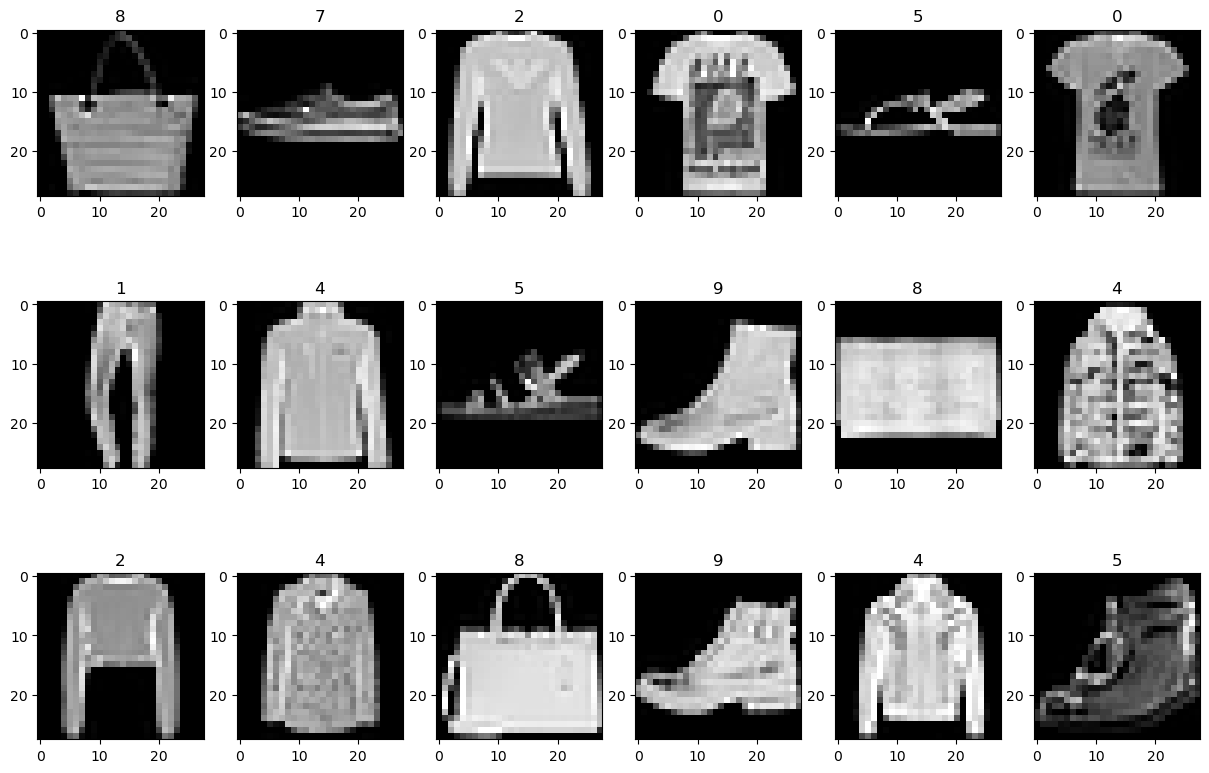

In [15]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

### Building the Classifier

We are now going to build the baseline classifier that you will use throughout this homework.

In [16]:
# Data normalization
x_train = x_train/255
x_test = x_test/255

In [17]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
epochs = 10
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 52ms/step - accuracy: 0.8194 - loss: 0.5358 - val_accuracy: 0.8827 - val_loss: 0.3243
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.9026 - loss: 0.2723 - val_accuracy: 0.8903 - val_loss: 0.3010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9192 - loss: 0.2262 - val_accuracy: 0.8914 - val_loss: 0.3083
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.9308 - loss: 0.1939 - val_accuracy: 0.8917 - val_loss: 0.3216
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9409 - loss: 0.1670 - val_accuracy: 0.8930 - val_loss: 0.3473
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9481 - loss: 0.1452 - val_accuracy: 0.8922 - val_loss: 0.3769
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9555 - loss: 0.1275 - val_accuracy: 0.8884 - val_loss: 0.4031
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9583 - loss: 0.1155 - 

Train Acc      0.9675499796867371
Validation Acc 0.8898000121116638


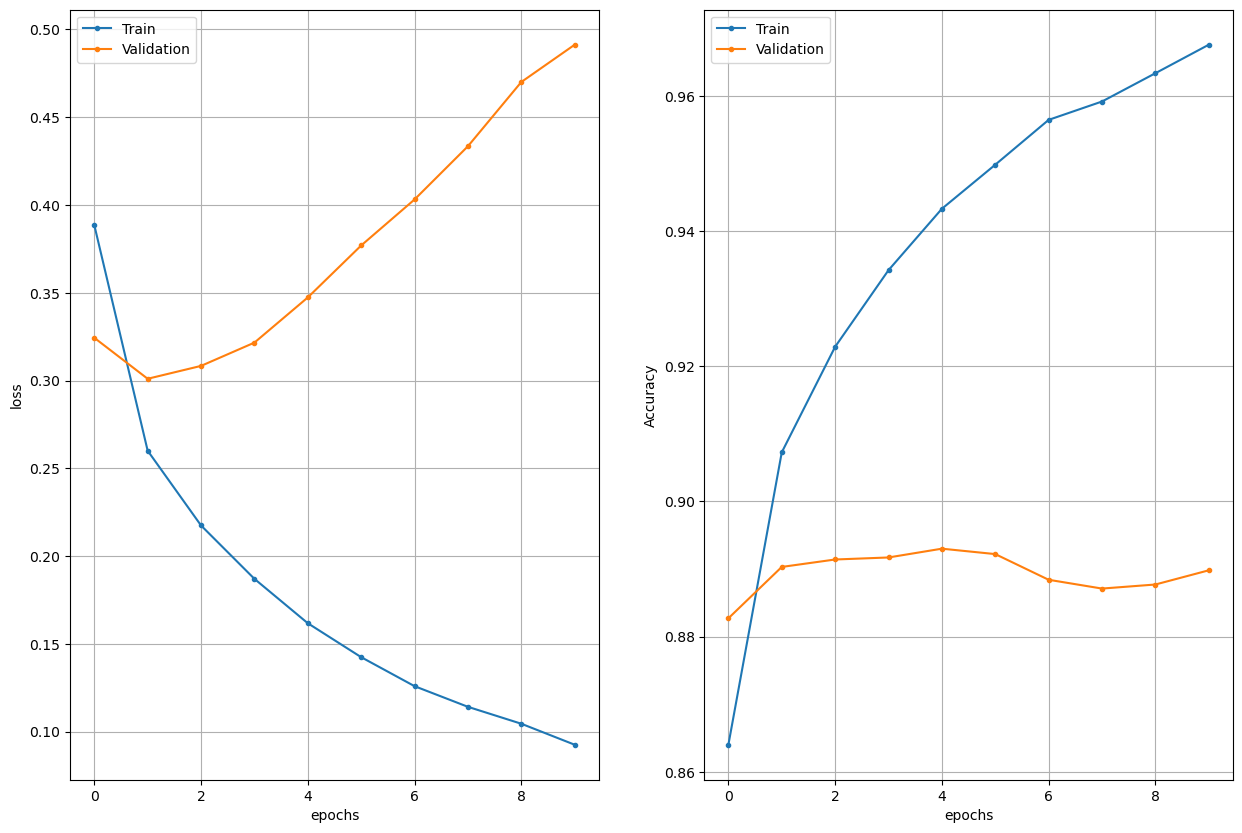

In [19]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
        
    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])
    
plot_history(history)

As you can see, the classifier suffers from massive overfitting. The validation accuracy is around 88% while the training accuracy is close to 1.

### Combat the Overfitting!

Now it is your turn. Use the classifier as a baseline, include some regularization techniques and try to improve the classification performance. You can try any techniques you might see fit, e.g.,
* Dropout
* Batch normalization
* Weight regularization
* Data augmentation
* Early stopping
* Pooling
* Reducing the number of parameters (the size of the network)
* ...

There are to objective you shall fulfill in order to successfully complete this homework:
* The validation accuracy shall be above 91%
* Your network (with all the regularizations applied) shall **not** be larger than the baseline

In [24]:
# Modify the baseline classifier in order to reduce the overfitting and make the performance more robust

# inputs = Input(shape=(28, 28, 1))
# net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
# net = Flatten()(net)
# net = Dense(128)(net)
# outputs = Dense(10, activation="softmax")(net)

# model = Model(inputs, outputs)
# model.summary()

inputs = Input(shape=(28, 28, 1))

# Block 1
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = BatchNormalization()(net)
net = MaxPooling2D(pool_size=(2, 2))(net)

# Block 2
net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = BatchNormalization()(net)
net = MaxPooling2D(pool_size=(2, 2))(net)

# Transition to Dense
net = Flatten()(net)
net = Dropout(0.4)(net) # Regularization
net = Dense(128, activation="relu")(net)
net = Dropout(0.3)(net) # Regularization

outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [30]:
# Train the network
EarlyStopping = tf.keras.callbacks.EarlyStopping

epochs = 5
batch_size = 256

# Define Early Stopping to prevent training once validation loss plateaus
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(
    x_train, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    validation_data=(x_test, y_test),
    callbacks=[es]
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.8786 - loss: 0.3434 - val_accuracy: 0.8782 - val_loss: 0.3323
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.9114 - loss: 0.2508 - val_accuracy: 0.8916 - val_loss: 0.3034
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.9253 - loss: 0.2083 - val_accuracy: 0.8959 - val_loss: 0.2920
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.9371 - loss: 0.1756 - val_accuracy: 0.8973 - val_loss: 0.2908
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.9461 - loss: 0.1510 - val_accuracy: 0.9003 - val_loss: 0.2976
Restoring model weights from the end of the best epoch: 4.


Train Acc      0.9479666948318481
Validation Acc 0.9003000259399414


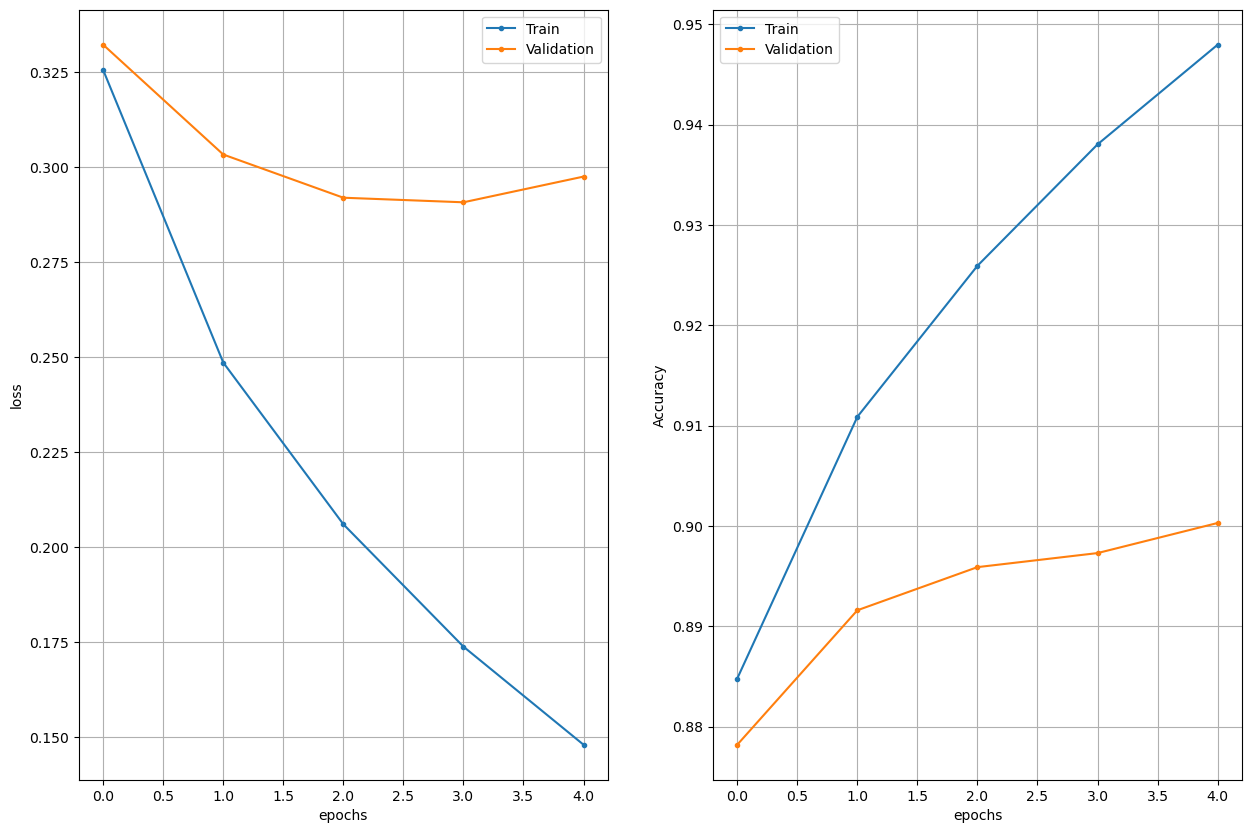

In [31]:
# Show the results
plot_history(history)


--- Running Experiment: 1. Baseline ---


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 60s 246ms/step - accuracy: 0.7422 - loss: 0.8163 - val_accuracy: 0.4023 - val_loss: 2.5158
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 73s 310ms/step - accuracy: 0.8685 - loss: 0.3589 - val_accuracy: 0.8198 - val_loss: 0.5085
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 264ms/step - accuracy: 0.8884 - loss: 0.3029 - val_accuracy: 0.8984 - val_loss: 0.2741
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 58s 245ms/step - accuracy: 0.9000 - loss: 0.2675 - val_accuracy: 0.9060 - val_loss: 0.2586
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 60s 255ms/step - accuracy: 0.9052 - loss: 0.2501 - val_accuracy: 0.9066 - val_loss: 0.2582

--- Ablation Study Results ---
                     train_acc  val_acc       gap
1. Baseline           0.935383   0.8982  0.037183
2. + Pooling          0.916667   0.8919  0.024767
3. + Extra Conv       0.911450   0.8954  0.016050
4. + Batch Norm       0.944417   0.9106  0.033817
5. + Dropout (Full)   0.906167   0.9066 -0.000433


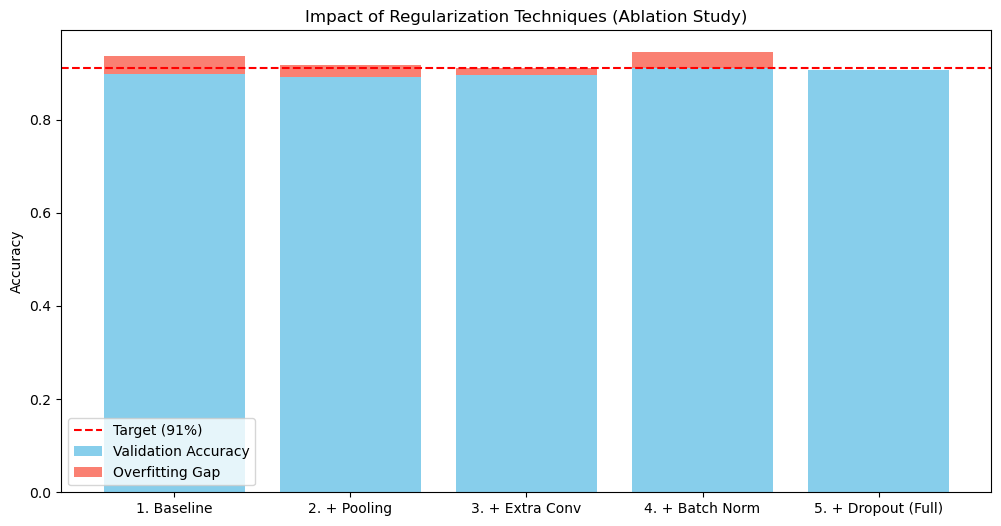

In [33]:
import pandas as pd

def build_ablated_model(use_pooling=False, extra_conv=False, use_bn=False, use_dropout=False):
    inputs = Input(shape=(28, 28, 1))
    
    # Block 1
    net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
    if use_bn: net = BatchNormalization()(net)
    if use_pooling: net = MaxPooling2D(pool_size=(2, 2))(net)
    
    # Block 2 (Extra Depth)
    if extra_conv:
        net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
        if use_bn: net = BatchNormalization()(net)
        if use_pooling: net = MaxPooling2D(pool_size=(2, 2))(net)
        
    net = Flatten()(net)
    
    # Regularization
    if use_dropout: net = Dropout(0.4)(net)
    
    net = Dense(128, activation="relu")(net)
    
    if use_dropout: net = Dropout(0.3)(net)
    
    outputs = Dense(10, activation="softmax")(net)
    
    return Model(inputs, outputs)

# Define the experiments
experiments = {
    "1. Baseline":             {"use_pooling": False, "extra_conv": False, "use_bn": False, "use_dropout": False},
    "2. + Pooling":            {"use_pooling": True,  "extra_conv": False, "use_bn": False, "use_dropout": False},
    "3. + Extra Conv":         {"use_pooling": True,  "extra_conv": True,  "use_bn": False, "use_dropout": False},
    "4. + Batch Norm":         {"use_pooling": True,  "extra_conv": True,  "use_bn": True,  "use_dropout": False},
    "5. + Dropout (Full)":     {"use_pooling": True,  "extra_conv": True,  "use_bn": True,  "use_dropout": True}
}

results = {}

for name, params in experiments.items():
    print(f"\n--- Running Experiment: {name} ---")
    model = build_ablated_model(**params)
    
    # Count parameters to ensure we stay below baseline
    model.summary()
    
    model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    
    # Using 20 epochs for the experiment to save time, but 50 is better for final results
    history = model.fit(
        x_train, y_train, 
        batch_size=256, 
        epochs=5, 
        validation_data=(x_test, y_test), 
        verbose=1 # Keep output clean
    )
    
    results[name] = {
        'train_acc': history.history['accuracy'][-1],
        'val_acc': history.history['val_accuracy'][-1],
        'gap': history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    }

# Display Summary Table
df_results = pd.DataFrame(results).T
print("\n--- Ablation Study Results ---")
print(df_results)

# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['val_acc'], label='Validation Accuracy', color='skyblue')
plt.bar(df_results.index, df_results['gap'], bottom=df_results['val_acc'], label='Overfitting Gap', color='salmon')
plt.axhline(y=0.91, color='r', linestyle='--', label='Target (91%)')
plt.ylabel('Accuracy')
plt.title('Impact of Regularization Techniques (Ablation Study)')
plt.legend()
plt.show()

### Questions

* What have you done in order to improve the performance?
    - spatial reduciton with maxpooling, dropuot, batch norm, ealy stopping, second conv layer
* Have you tried configurations that did not work out?
    - tried a 50% dropout on all layers, but this led to underfitting, where the training accuracy wouldn't even reach 85%